# 08 — Results & Comparison

Final analysis notebook. Loads saved results from all four trained models and produces a complete comparison.

**Models:** Custom CNN · ResNet50 · EfficientNet-B2 · ViT-B/16  
**Dataset:** PlantVillage (21-class subset, color images)  
**Split:** 70 / 15 / 15 stratified, seed=42

**Sections:**
1. Setup & load results
2. Summary table
3. Accuracy bar chart
4. Training curve overlay *(skipped for ViT — run with --eval-only)*
5. Per-class F1 heatmap
6. Hardest classes analysis
7. Accuracy vs parameter count
8. Precision / Recall breakdown
9. Grad-CAM visualisations
10. Final summary

## 1. Setup

In [6]:
import os, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
warnings.filterwarnings('ignore')

# ── Colab upload helper ───────────────────────────────────────────────────────
# If running in Colab, upload your JSON files and set PROC_DIR = '.'
# If running on the cluster, set LEAF_PRED_ROOT and it will resolve automatically.
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_DIR    = os.environ.get('LEAF_PRED_ROOT', os.path.expanduser('~/leaf-pred'))
PROC_DIR    = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Override to current dir when running in Colab with uploaded files
if IN_COLAB and not os.path.exists(os.path.join(PROC_DIR, 'results_custom_cnn.json')):
    PROC_DIR = '.'
    print('Colab mode: reading JSON files from current directory.')
    print('Make sure you have uploaded: results_custom_cnn.json, results_resnet50.json,')
    print('                             results_efficientnet_b2.json, results_vit_b16.json')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

# ── Colour palette (consistent across all plots) ──────────────────────────────
MODEL_KEYS   = ['custom_cnn', 'resnet50', 'efficientnet_b2', 'vit_b16']
MODEL_LABELS = ['Custom CNN', 'ResNet50', 'EfficientNet-B2', 'ViT-B/16']
MODEL_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
MODEL_PARAMS = {k: v for k, v in zip(MODEL_KEYS, [4_855_302, 24_576_614, 8_441_896, 86_211_878])}

Colab mode: reading JSON files from current directory.
Make sure you have uploaded: results_custom_cnn.json, results_resnet50.json,
                             results_efficientnet_b2.json, results_vit_b16.json
Device : cuda


In [7]:
# ── Load results ──────────────────────────────────────────────────────────────
results = {}
for key in MODEL_KEYS:
    path = os.path.join(PROC_DIR, f'results_{key}.json')
    if os.path.exists(path):
        with open(path, 'r') as f:
            d = json.load(f)
        # Sanitise ViT best_val_loss=Infinity (from --eval-only run)
        if not math.isfinite(d.get('best_val_loss', 0)):
            d['best_val_loss'] = None
        results[key] = d
        print(f'  Loaded : results_{key}.json')
    else:
        print(f'  MISSING: {path}')

available_keys   = [k for k in MODEL_KEYS if k in results]
available_labels = [MODEL_LABELS[MODEL_KEYS.index(k)] for k in available_keys]
available_colors = [MODEL_COLORS[MODEL_KEYS.index(k)] for k in available_keys]

# ── Extract class names from the per_class keys ───────────────────────────────
# Keys are already the display names (truncated to 15 chars during evaluation)
SKIP_KEYS = {'accuracy', 'macro avg', 'weighted avg'}
first = results[available_keys[0]]
CLASS_NAMES = [k for k in first['per_class'].keys() if k not in SKIP_KEYS]
N_CLASSES   = len(CLASS_NAMES)

print(f'\nModels loaded : {len(available_keys)}/{len(MODEL_KEYS)}')
print(f'Classes       : {N_CLASSES}')

  Loaded : results_custom_cnn.json
  Loaded : results_resnet50.json
  Loaded : results_efficientnet_b2.json
  Loaded : results_vit_b16.json

Models loaded : 4/4
Classes       : 21


## 2. Summary Table

In [8]:
rows = []
for key, label in zip(available_keys, available_labels):
    r   = results[key]
    pc  = r['per_class']
    f1s = [pc[c]['f1-score'] for c in CLASS_NAMES]
    rows.append({
        'Model':           label,
        'Test Accuracy %': round(r['test_accuracy'] * 100, 2),
        'Macro F1':        round(sum(f1s) / len(f1s), 4),
        'Best Val Loss':   round(r['best_val_loss'], 4) if r['best_val_loss'] is not None else 'N/A (eval-only)',
        'Parameters':      f"{r['n_params']:,}",
        'Epochs':          len(r['history']['train_loss']) if r['history']['train_loss'] else 'N/A',
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())
summary_df.to_csv(os.path.join(RESULTS_DIR, '08_summary_table.csv'))
print('\nSaved → 08_summary_table.csv')

                 Test Accuracy %  Macro F1  Best Val Loss  Parameters  Epochs
Model                                                                        
Custom CNN                 96.81    0.9618         0.0753   4,855,302      50
ResNet50                   99.79    0.9953         0.0133  24,576,614      30
EfficientNet-B2            98.92    0.9794         0.0332   8,441,896      30
ViT-B/16                   99.50    0.9892         0.0169  86,211,878      30

Saved → 08_summary_table.csv


## 3. Accuracy & Macro F1 Bar Chart

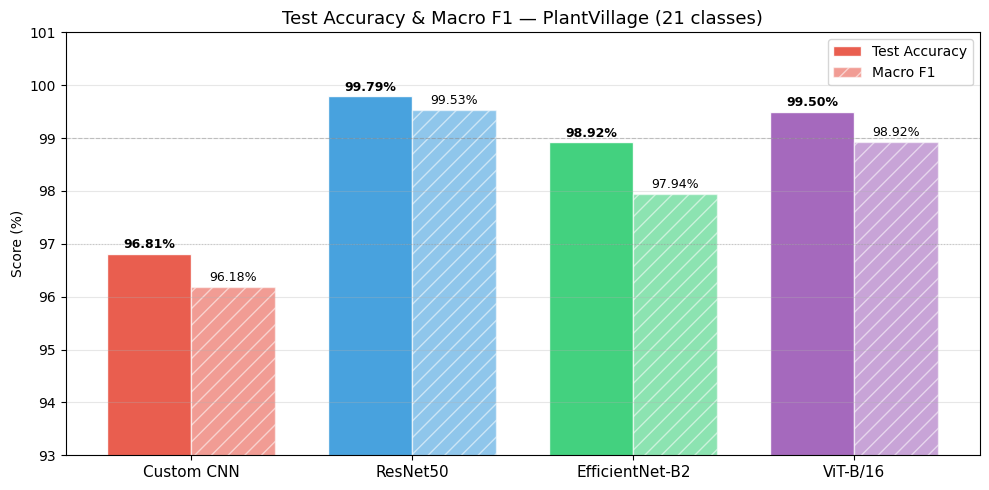

Saved → 08_accuracy_comparison.png


In [9]:
accuracies = [results[k]['test_accuracy'] * 100 for k in available_keys]
pc_data    = [results[k]['per_class'] for k in available_keys]
macro_f1s  = [sum(d[c]['f1-score'] for c in CLASS_NAMES) / N_CLASSES * 100 for d in pc_data]

x      = np.arange(len(available_labels))
width  = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
bars_acc = ax.bar(x - width/2, accuracies, width, label='Test Accuracy',
                   color=available_colors, alpha=0.9, edgecolor='white')
bars_f1  = ax.bar(x + width/2, macro_f1s,  width, label='Macro F1',
                   color=available_colors, alpha=0.55, edgecolor='white', hatch='//')

for bar, val in zip(bars_acc, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars_f1, macro_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(available_labels, fontsize=11)
ax.set_ylim(93, 101)
ax.set_ylabel('Score (%)')
ax.set_title('Test Accuracy & Macro F1 — PlantVillage (21 classes)', fontsize=13)
ax.axhline(99, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
ax.axhline(97, color='gray', linestyle=':', alpha=0.3, linewidth=0.8)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '08_accuracy_comparison.png'), dpi=150)
plt.show()
print('Saved → 08_accuracy_comparison.png')

## 4. Training Curve Overlay

*Note: ViT was run with `--eval-only` so has no training history — it is excluded from these curves.*

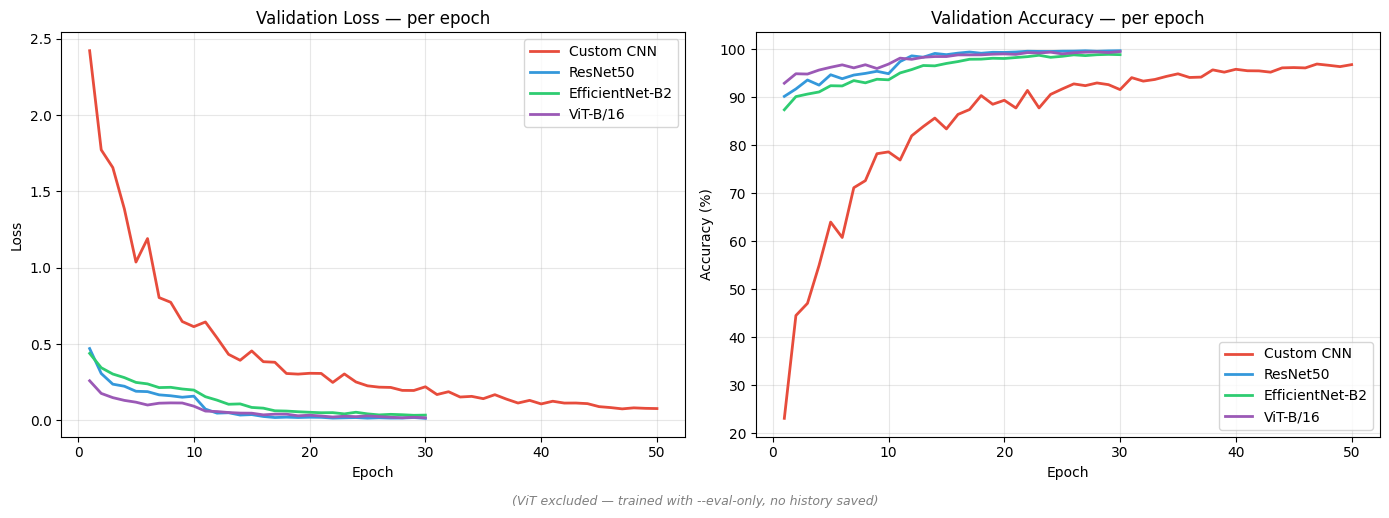

Saved → 08_training_curves_overlay.png


In [10]:
# Only plot models that have training history
keys_with_history = [k for k in available_keys if results[k]['history']['train_loss']]

if not keys_with_history:
    print('No training history available for any model.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for key in keys_with_history:
        label  = MODEL_LABELS[MODEL_KEYS.index(key)]
        color  = MODEL_COLORS[MODEL_KEYS.index(key)]
        h      = results[key]['history']
        epochs = range(1, len(h['val_loss']) + 1)
        axes[0].plot(epochs, h['val_loss'], label=label, color=color, linewidth=2)
        axes[1].plot(epochs, [v * 100 for v in h['val_acc']], label=label, color=color, linewidth=2)

    axes[0].set_title('Validation Loss — per epoch', fontsize=12)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title('Validation Accuracy — per epoch', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    note = '(ViT excluded — trained with --eval-only, no history saved)'
    fig.text(0.5, -0.02, note, ha='center', fontsize=9, color='gray', style='italic')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, '08_training_curves_overlay.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → 08_training_curves_overlay.png')

## 5. Per-Class F1 Heatmap

Shows F1 score for each of the 21 disease classes across all four models. Red = poor, green = perfect.

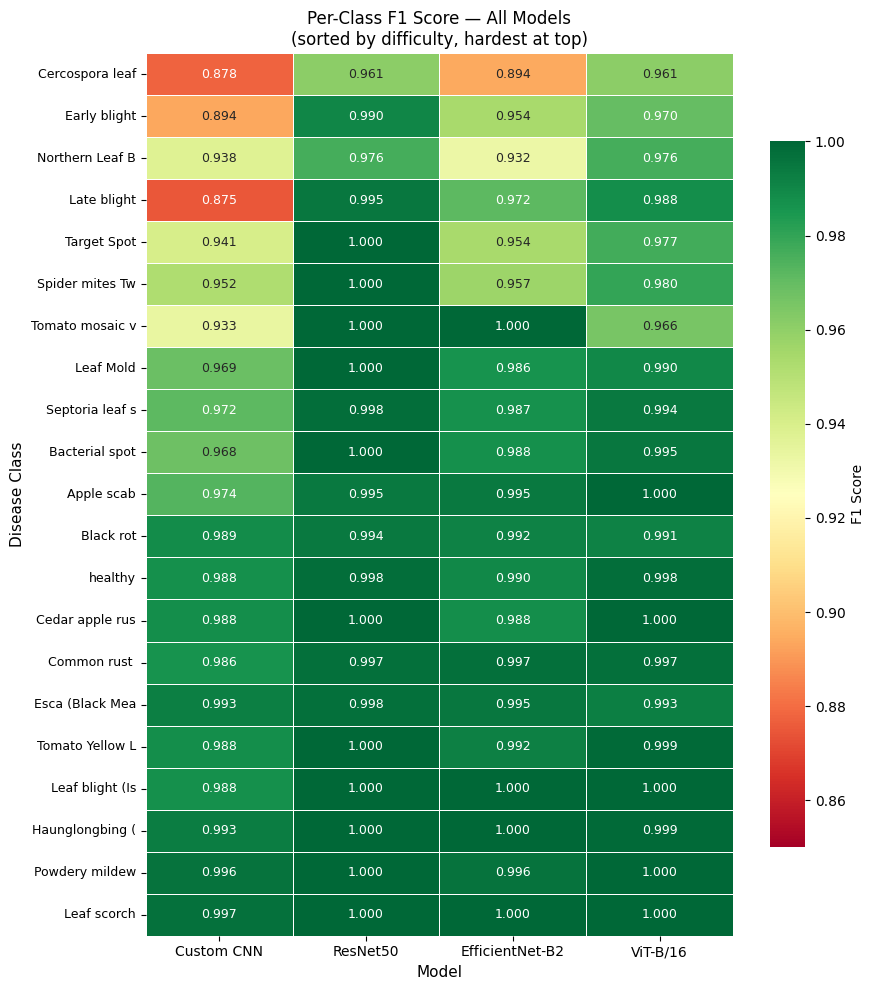

Saved → 08_f1_heatmap.png


In [11]:
f1_matrix = np.zeros((N_CLASSES, len(available_keys)))
for col, key in enumerate(available_keys):
    for row, cls in enumerate(CLASS_NAMES):
        f1_matrix[row, col] = results[key]['per_class'][cls]['f1-score']

f1_df = pd.DataFrame(
    f1_matrix,
    index=CLASS_NAMES,
    columns=available_labels
)

# Sort rows by mean F1 ascending so hardest classes are at top
f1_df = f1_df.loc[f1_df.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(
    f1_df, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.85, vmax=1.0, ax=ax,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'label': 'F1 Score', 'shrink': 0.8}
)
ax.set_title('Per-Class F1 Score — All Models\n(sorted by difficulty, hardest at top)', fontsize=12)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Disease Class', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '08_f1_heatmap.png'), dpi=150)
plt.show()
print('Saved → 08_f1_heatmap.png')

## 6. Hardest Classes Analysis

Ranks all 21 classes by mean F1 across models, with error bars showing variance between models.

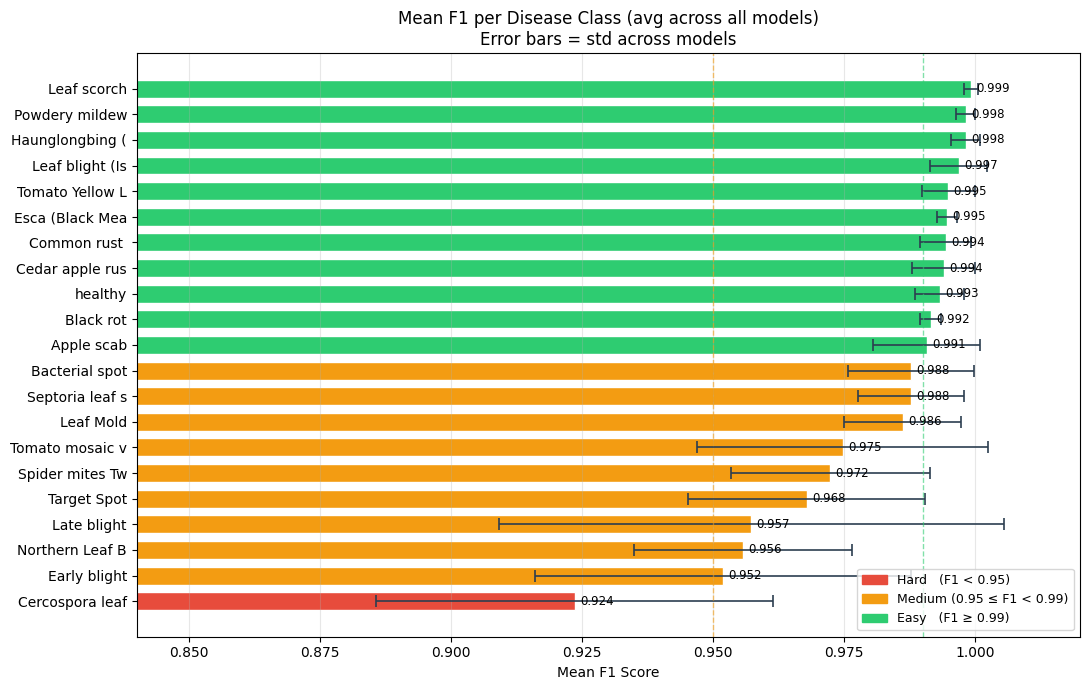

5 hardest classes (by mean F1 across models):
  Cercospora leaf         mean F1=0.9236  std=0.0379
  Early blight            mean F1=0.9519  std=0.0359
  Northern Leaf B         mean F1=0.9557  std=0.0208
  Late blight             mean F1=0.9573  std=0.0482
  Target Spot             mean F1=0.9678  std=0.0226

Saved → 08_hardest_classes.png


In [12]:
mean_f1 = f1_matrix.mean(axis=1)   # already sorted above via f1_df reindex
std_f1  = f1_matrix.std(axis=1)
sorted_idx = mean_f1.argsort()     # resort since f1_matrix rows match original CLASS_NAMES order

sorted_classes = [CLASS_NAMES[i] for i in sorted_idx]
sorted_mean    = mean_f1[sorted_idx]
sorted_std     = std_f1[sorted_idx]

bar_colors = ['#e74c3c' if f < 0.95 else '#f39c12' if f < 0.99 else '#2ecc71'
              for f in sorted_mean]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(sorted_classes, sorted_mean, color=bar_colors,
               edgecolor='white', height=0.7)
ax.errorbar(sorted_mean, sorted_classes,
            xerr=sorted_std, fmt='none', color='#2c3e50',
            capsize=4, linewidth=1.2, capthick=1.2)

# Value labels
for bar, val in zip(bars, sorted_mean):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5)

ax.axvline(0.99, color='#2ecc71', linestyle='--', alpha=0.6, linewidth=1, label='F1 = 0.99')
ax.axvline(0.95, color='#f39c12', linestyle='--', alpha=0.6, linewidth=1, label='F1 = 0.95')
ax.set_xlim(0.84, 1.02)
ax.set_title('Mean F1 per Disease Class (avg across all models)\nError bars = std across models', fontsize=12)
ax.set_xlabel('Mean F1 Score')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Hard   (F1 < 0.95)'),
    mpatches.Patch(color='#f39c12', label='Medium (0.95 ≤ F1 < 0.99)'),
    mpatches.Patch(color='#2ecc71', label='Easy   (F1 ≥ 0.99)'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '08_hardest_classes.png'), dpi=150)
plt.show()

print('5 hardest classes (by mean F1 across models):')
for cls, mean, std in zip(sorted_classes[:5], sorted_mean[:5], sorted_std[:5]):
    print(f'  {cls:<22}  mean F1={mean:.4f}  std={std:.4f}')
print('\nSaved → 08_hardest_classes.png')

## 7. Accuracy vs Parameter Count

The efficiency frontier — how much accuracy do you get per parameter?

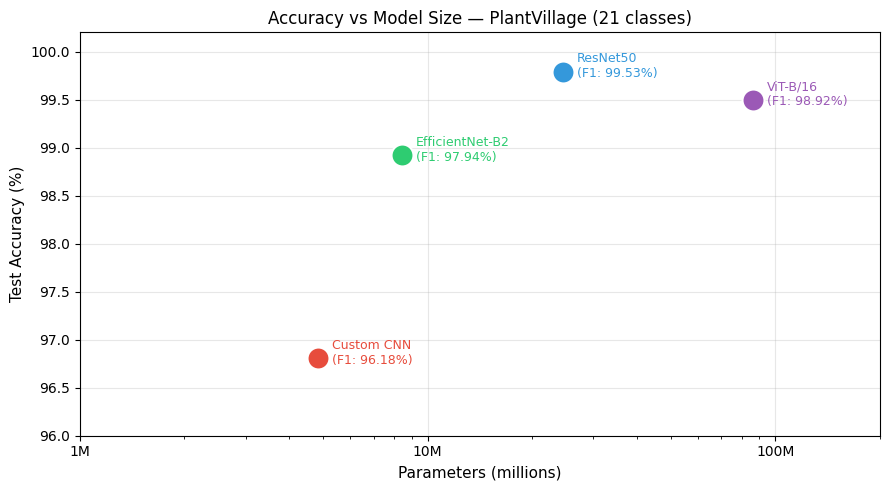

Saved → 08_accuracy_vs_params.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

for key, label, color in zip(available_keys, available_labels, available_colors):
    r      = results[key]
    params = r['n_params'] / 1e6
    acc    = r['test_accuracy'] * 100
    pc     = r['per_class']
    mf1    = sum(pc[c]['f1-score'] for c in CLASS_NAMES) / N_CLASSES * 100

    ax.scatter(params, acc, s=250, color=color, zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(
        f'{label}\n(F1: {mf1:.2f}%)',
        (params, acc),
        textcoords='offset points',
        xytext=(10, -4),
        fontsize=9,
        color=color
    )

ax.set_xlabel('Parameters (millions)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Model Size — PlantVillage (21 classes)', fontsize=12)
ax.set_xscale('log')   # log scale because ViT is 10x larger than others
ax.set_xlim(1, 200)
ax.set_ylim(96, 100.2)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '08_accuracy_vs_params.png'), dpi=150)
plt.show()
print('Saved → 08_accuracy_vs_params.png')

## 8. Precision / Recall Breakdown per Model

For each model, plots precision vs recall per class to reveal whether errors are false positives (low precision) or false negatives (low recall).

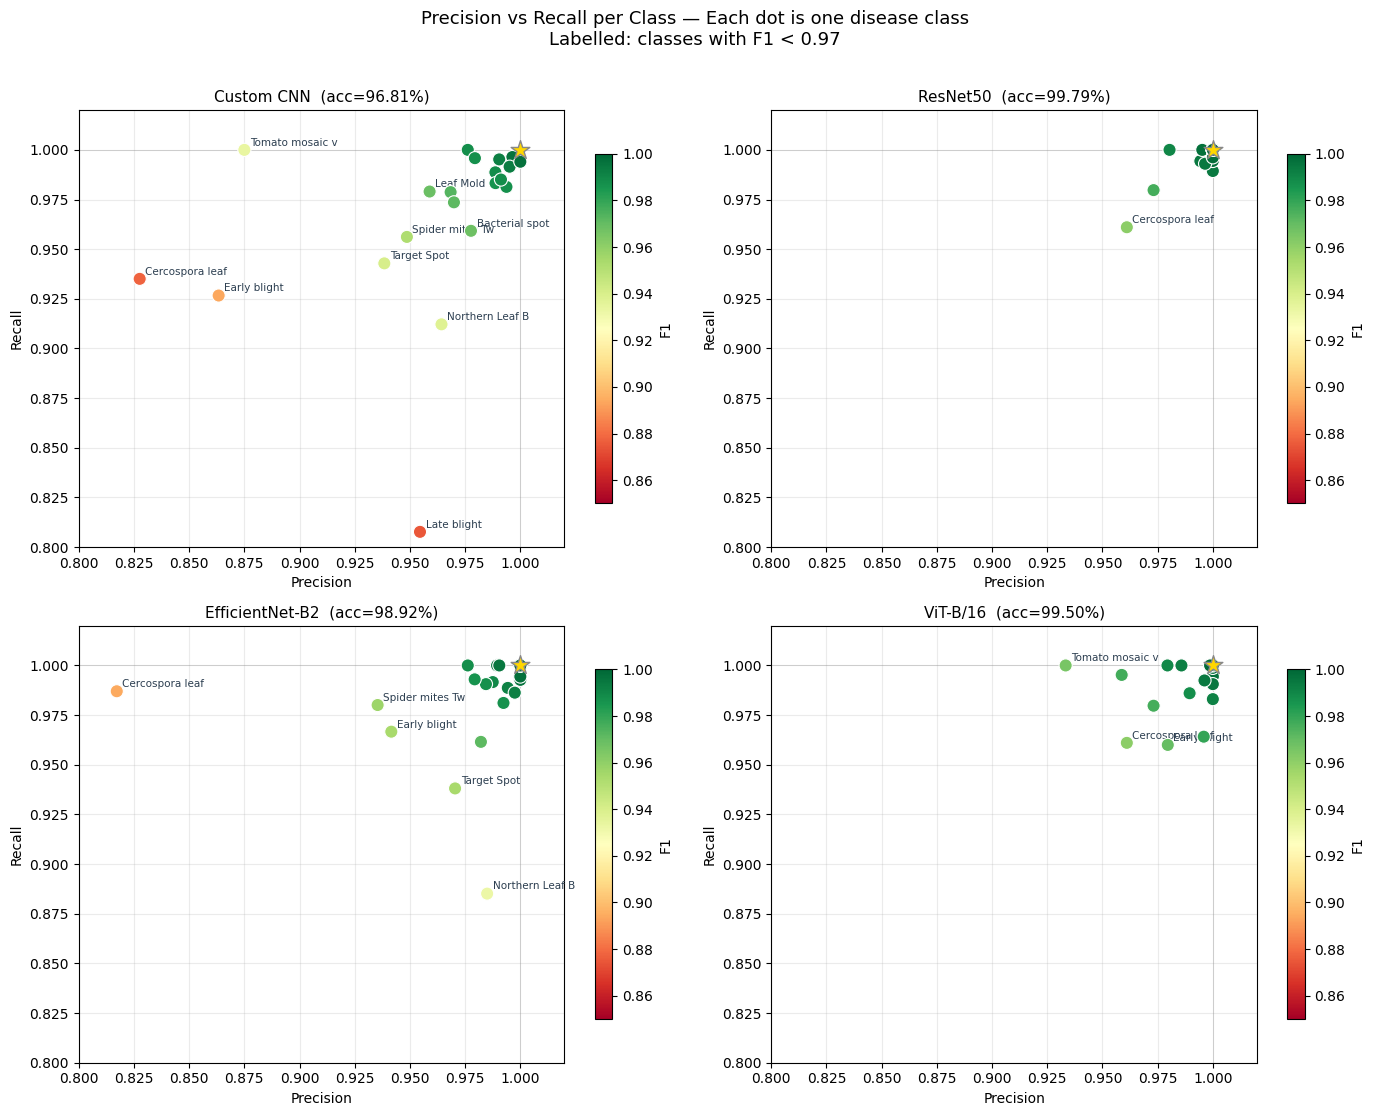

Saved → 08_precision_recall.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax_i, (key, label, color) in enumerate(zip(available_keys, available_labels, available_colors)):
    ax  = axes[ax_i]
    pc  = results[key]['per_class']
    prec = [pc[c]['precision'] for c in CLASS_NAMES]
    rec  = [pc[c]['recall']    for c in CLASS_NAMES]
    f1s  = [pc[c]['f1-score']  for c in CLASS_NAMES]

    sc = ax.scatter(prec, rec, c=f1s, cmap='RdYlGn', vmin=0.85, vmax=1.0,
                    s=90, edgecolors='white', linewidths=0.8, zorder=4)

    # Label only the outlier classes (F1 < 0.97)
    for cls, p, r, f in zip(CLASS_NAMES, prec, rec, f1s):
        if f < 0.97:
            ax.annotate(cls, (p, r), fontsize=7.5, textcoords='offset points',
                        xytext=(4, 3), color='#2c3e50')

    # Perfect point
    ax.scatter([1.0], [1.0], marker='*', s=200, color='gold',
               edgecolors='#888', zorder=5, label='Perfect')

    ax.set_xlim(0.80, 1.02)
    ax.set_ylim(0.80, 1.02)
    ax.set_xlabel('Precision', fontsize=10)
    ax.set_ylabel('Recall', fontsize=10)
    ax.set_title(f'{label}  (acc={results[key]["test_accuracy"]*100:.2f}%)', fontsize=11)
    ax.axhline(1, color='gray', linewidth=0.5, alpha=0.4)
    ax.axvline(1, color='gray', linewidth=0.5, alpha=0.4)
    ax.grid(alpha=0.25)
    plt.colorbar(sc, ax=ax, label='F1', shrink=0.8)

fig.suptitle('Precision vs Recall per Class — Each dot is one disease class\n'
             'Labelled: classes with F1 < 0.97', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '08_precision_recall.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → 08_precision_recall.png')

## 9. Final Summary

In [15]:
print('=' * 65)
print('  FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'  Dataset   : PlantVillage (color), {N_CLASSES} classes')
print(f'  Split     : 70/15/15 stratified, seed=42')
print()
print(f'  {"Model":<20} {"Acc %":>7}  {"Macro F1":>9}  {"Params":>12}  {"Val Loss"}')
print(f'  {"-"*20} {"-"*7}  {"-"*9}  {"-"*12}  {"-"*10}')

best_acc   = 0
best_model = ''
best_eff   = 0
best_eff_model = ''

for key, label in zip(available_keys, available_labels):
    r      = results[key]
    acc    = r['test_accuracy'] * 100
    pc     = r['per_class']
    mf1    = sum(pc[c]['f1-score'] for c in CLASS_NAMES) / N_CLASSES
    params = r['n_params'] / 1e6
    vl     = f"{r['best_val_loss']:.4f}" if r['best_val_loss'] is not None else 'N/A'
    print(f'  {label:<20} {acc:>7.2f}%  {mf1:>9.4f}  {params:>10.1f}M  {vl}')

    if acc > best_acc:
        best_acc   = acc
        best_model = label
    eff = acc / params
    if eff > best_eff:
        best_eff       = eff
        best_eff_model = label

print()
print(f'  Best accuracy          : {best_model} ({best_acc:.2f}%)')
print(f'  Best accuracy/param    : {best_eff_model} (most efficient)')
print()
print('  Saved to results/:')
for fname in ['08_summary_table.csv', '08_accuracy_comparison.png',
              '08_training_curves_overlay.png', '08_f1_heatmap.png',
              '08_hardest_classes.png', '08_accuracy_vs_params.png',
              '08_precision_recall.png', '08_gradcam.png']:
    print(f'    {fname}')
print()
print('=' * 65)
print('  PROJECT COMPLETE')
print('=' * 65)

  FINAL RESULTS SUMMARY
  Dataset   : PlantVillage (color), 21 classes
  Split     : 70/15/15 stratified, seed=42

  Model                  Acc %   Macro F1        Params  Val Loss
  -------------------- -------  ---------  ------------  ----------
  Custom CNN             96.81%     0.9618         4.9M  0.0753
  ResNet50               99.79%     0.9953        24.6M  0.0133
  EfficientNet-B2        98.92%     0.9794         8.4M  0.0332
  ViT-B/16               99.50%     0.9892        86.2M  0.0169

  Best accuracy          : ResNet50 (99.79%)
  Best accuracy/param    : Custom CNN (most efficient)

  Saved to results/:
    08_summary_table.csv
    08_accuracy_comparison.png
    08_training_curves_overlay.png
    08_f1_heatmap.png
    08_hardest_classes.png
    08_accuracy_vs_params.png
    08_precision_recall.png
    08_gradcam.png

  PROJECT COMPLETE
